# RECAP - Bu not defterini Google Colab ile açın ;)

In [1]:
import os, sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

# 1. Wine review Kaggle challenge'dan verileri yükleyin

### CSV dosyasını indirin (örneğin Kaggle API kullanarak)

In [2]:
!pip install kaggle --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Ardından, Kaggle hesabınıza gidin ve “Yeni API TOKEN” oluşturun. Bilgisayarınıza kaydedebileceğiniz bir dosyanın indirilmesi başlayacaktır. Şimdi, bu dosyayı aşağıdaki komutla yüklemeniz gerekir:

In [3]:
import pandas as pd

df = pd.read_csv("winemag-data-130k-v2.csv")
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


Bu işlem tamamlandıktan sonra, şunu çalıştırın:

In [4]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
# Give read & write rights
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/home/doruk/.kaggle/kaggle.json': No such file or directory


Artık veri setini aşağıdaki bağlantıdan indirebilirsiniz:

In [5]:
!kaggle datasets download -d zynicide/wine-reviews

Dataset URL: https://www.kaggle.com/datasets/zynicide/wine-reviews
License(s): CC-BY-NC-SA-4.0
100%|██████████████████████████████████████| 50.9M/50.9M [00:09<00:00, 5.63MB/s]



Artık dosyaları açabiliriz.

In [6]:
import zipfile
zip_ref = zipfile.ZipFile('wine-reviews.zip', 'r')
zip_ref.extractall('files')
zip_ref.close()

İndirdiğiniz dosyaları kontrol edelim:

In [7]:
!ls files

winemag-data-130k-v2.csv  winemag-data-130k-v2.json  winemag-data_first150k.csv


### RAM'e yükleme

In [8]:
import pandas as pd
import os

df = pd.read_csv("winemag-data-130k-v2.csv", index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [9]:
print(df.shape)
df.head(3)

(129971, 13)


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm


Veri kümesinin her satırı bir şarap tanımına karşılık gelir. Verilerde neler olduğunu, özellikle de farklı sütunları inceleyelim:
- şarap şişesinin fiyatı
- tanımı
- sahip olduğu “puan” sayısı (0 ile 100 arasında bir ölçekte)

Buradaki amaç veri mühendisliği yapmak değildir. Öyleyse, ilgili satırları kaldırarak eksik değerleri halledelim.

In [10]:
df = df.dropna()
df.shape

(22387, 13)

# 2. Şişe Açıklamasından Şarap Fiyatını Tahmin Etme

### X,y Oluştur

Eğitim setimizi oluşturun

In [11]:
X_text = df['description'].values
y = df['price'].values

Bunu kelimelere ayıralım

In [12]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence
X_words = [text_to_word_sequence(sentence) for sentence in X_text]
X_words[0]

I0000 00:00:1780471066.567266   35598 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780471066.568080   35598 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780471066.621259   35598 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780471068.008840   35598 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

['much',
 'like',
 'the',
 'regular',
 'bottling',
 'from',
 '2012',
 'this',
 'comes',
 'across',
 'as',
 'rather',
 'rough',
 'and',
 'tannic',
 'with',
 'rustic',
 'earthy',
 'herbal',
 'characteristics',
 'nonetheless',
 'if',
 'you',
 'think',
 'of',
 'it',
 'as',
 'a',
 'pleasantly',
 'unfussy',
 'country',
 'wine',
 "it's",
 'a',
 'good',
 'companion',
 'to',
 'a',
 'hearty',
 'winter',
 'stew']

Bir sonraki adım, kelimelerinizi tokenlere dönüştürmektir, çünkü bilgisayar bu tokenlerle çalışacaktır.

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer

tk = Tokenizer()
tk.fit_on_texts(X_words)
X_tokens = tk.texts_to_sequences(X_text)

# Vocab size?
vocab_size = len(tk.word_index)
vocab_size

16075

Şimdi, **verileri doldurmamız** gerekiyor. Önce `sentence_length` değerini kontrol edelim.

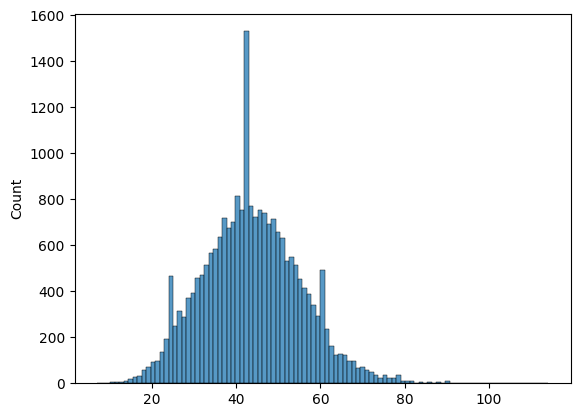

In [14]:
import seaborn as sns
sns.histplot([len(x) for x in X_tokens]);

In [15]:
# max_length_padding seçin
maxlen = 60

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_pad = pad_sequences(X_tokens, dtype=float, padding='post', maxlen=maxlen)
X_pad.shape

(22387, 60)

### NLP model

In [17]:
# Her zaman ortalama fiyatı tahmin ederken temel MAE puanı
y_mean = y.mean()
mae_baseline = np.mean(np.abs(y - y_mean))
print("MAE Baseline:", f"{mae_baseline:.2f}$")

MAE Baseline: 17.73$


Öncelikle bir NLP modeli oluşturalım. Bu sefer işlevsel API'yi kullanacağız. Sadece eğlence için değil. Nedenini daha sonra göreceksiniz.

In [18]:
# Embedding boyutu?
embedding_size = 40

In [19]:
from tensorflow.keras import Model, Input, layers
from tensorflow.keras.optimizers import Adam

# Model girdilerini, katmanlarını ve çıktılarını tanımlayın
inputs_nlp = Input(shape=(maxlen,))
x = layers.Embedding(input_dim=vocab_size+1, output_dim=embedding_size, mask_zero=True)(inputs_nlp)
x = layers.Conv1D(10, kernel_size=15, padding='same', activation="relu")(x)
x = layers.Conv1D(10, kernel_size=10, padding='same', activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(30, activation='relu')(x)
x = layers.Dropout(0.15)(x)
outputs_nlp = layers.Dense(1, activation='relu')(x)

# Modeli tanımlayın
model_nlp = Model(inputs=inputs_nlp, outputs=outputs_nlp)

model_nlp.summary()

E0000 00:00:1780471070.892286   35598 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/doruk/.pyenv/versions/workintech/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 40)         │       643,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 10)         │         6,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 10)         │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │        18,030 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,121 (2.55 MB)

 Trainable params: 668,121 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

### TensorBoard'a hoş geldiniz 😎!
Bu, Sinir Ağının nasıl eğitildiğini görmek için harika bir araçtır.

In [20]:
# TensorBoard notebook uzantısını yükleyin
%load_ext tensorboard

# Önceki çalışmalardan kalan tüm logları temizle
!rm -rf ./logs/

# logları bir klasörde saklayacağız (her fit için bir klasör)
import datetime
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

Şimdi, fit'lerimizin günlükleri, TensorBoard'un ihtiyaç duyduğu bazı bilgileri depolayan özel olarak tasarlanmış bir klasöre verilecektir.

In [22]:
from tensorflow.keras.callbacks import TensorBoard
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(patience=2)

model_nlp.compile(loss="mse", optimizer=Adam(learning_rate=1e-4), metrics=['mae'])

model_nlp.fit(X_pad, y,
          validation_split=0.3,
          epochs=50,
          batch_size=32,
          callbacks=[es, tensorboard_callback]
          )

Epoch 1/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 532.5513 - mae: 14.7341 - val_loss: 1098.7672 - val_mae: 14.9419
Epoch 2/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 492.6514 - mae: 14.0562 - val_loss: 1077.4340 - val_mae: 14.4908
Epoch 3/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 467.2766 - mae: 13.6685 - val_loss: 1067.3636 - val_mae: 14.1780
Epoch 4/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 437.3971 - mae: 13.2288 - val_loss: 1052.8065 - val_mae: 14.2753
Epoch 5/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 423.2572 - mae: 12.9193 - val_loss: 1045.8456 - val_mae: 14.1061
Epoch 6/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 401.5677 - mae: 12.5931 - val_loss: 1044.4270 - val_mae: 14.0467
Epoch 7/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 385.0287 - mae: 12.3520 - val_loss: 1041.5251 - val_mae: 14.2466
Epoch 8/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 362.2104 - mae: 12.0531 - val_loss: 1041.8972 - val_mae: 

In [23]:
%tensorboard --logdir logs/fit

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/home/doruk/.pyenv/versions/workintech/bin/tensorboard", line 3, in <module>
    from tensorboard.main import run_main
  File "/home/doruk/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/home/doruk/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

# 3. Sayısal özelliklerden fiyatı tahmin etmek?

Örneğin, her şişenin puanları (0 ila 100 arasında bir ölçekte), bir şarabın ne kadar ucuz veya pahalı olabileceğini bize söylemelidir.

(0.0, 200.0)

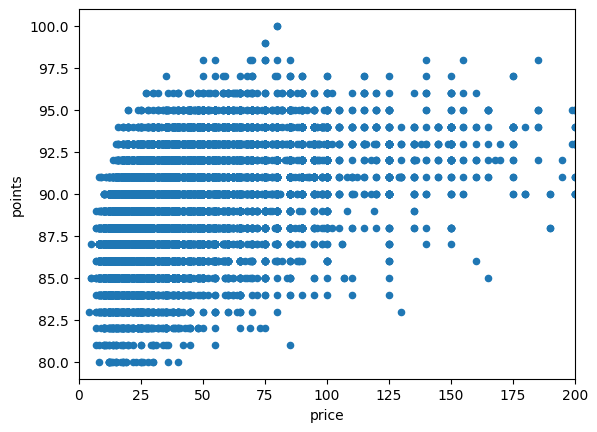

In [24]:
df.plot.scatter('price', 'points')
plt.xlim(0, 200)

In [25]:
# Başka hangi kategorik değişkenleri One Hot Encoding ile kodlayabiliriz?
df.nunique()

country                      1
description              20491
designation               9515
points                      21
price                      146
province                     4
region_1                   171
region_2                    17
taster_name                 11
taster_twitter_handle       11
title                    20425
variety                    183
winery                    2791
dtype: int64

In [26]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
X_region_ohe = ohe.fit_transform(df[['region_2']]) # Buraya diğer sütunları ekleyin

In [27]:
# Price ve OHE sütunlarını birleştirin
X_num = np.hstack([df[['points']].values, X_region_ohe])
pd.DataFrame(X_num)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,87.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,87.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,86.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22382,91.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22383,91.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22384,90.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22385,90.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# Her şeyi ölçeklendirin
from sklearn.preprocessing import StandardScaler
X_num = StandardScaler().fit_transform(X_num)
print(X_num.shape)
pd.DataFrame(X_num).head()

(22387, 18)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-0.903379,-0.165381,-0.514728,-0.165095,-0.572897,-0.062099,-0.050077,-0.307155,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,-0.419860,-0.087992,-0.148966,-0.119078,2.756893
1,-0.903379,-0.165381,-0.514728,-0.165095,-0.572897,-0.062099,-0.050077,3.255685,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,-0.419860,-0.087992,-0.148966,-0.119078,-0.362727
2,-0.903379,-0.165381,1.942773,-0.165095,-0.572897,-0.062099,-0.050077,-0.307155,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,-0.419860,-0.087992,-0.148966,-0.119078,-0.362727
3,-0.903379,-0.165381,-0.514728,-0.165095,-0.572897,-0.062099,-0.050077,-0.307155,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,2.381749,-0.087992,-0.148966,-0.119078,-0.362727
4,-1.259347,-0.165381,-0.514728,-0.165095,-0.572897,-0.062099,-0.050077,-0.307155,-0.132107,-0.022172,-0.111725,-0.13488,-0.205134,-0.419860,-0.087992,-0.148966,-0.119078,2.756893


In [29]:
# Model girdilerini, katmanlarını ve çıktılarını tanımlayın
inputs_num = Input(shape=(X_num.shape[1],))
x = layers.Dense(64, activation="relu")(inputs_num)
x = layers.Dense(32, activation="relu")(x)
outputs_num = layers.Dense(1, activation="relu")(x)

# Modeli tanımlayın
model_num = Model(inputs=inputs_num, outputs=outputs_num)

model_num.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
es = EarlyStopping(patience=2)

model_num.compile(loss = "mse", optimizer=Adam(learning_rate=5e-4), metrics=['mae'])
model_num.fit(X_num, y,
          validation_split=0.3,
          epochs=50,
          batch_size=32,
          callbacks=[es]
          )

Epoch 1/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1209.0790 - mae: 24.4120 - val_loss: 1030.4727 - val_mae: 14.2600
Epoch 2/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 454.4635 - mae: 13.5800 - val_loss: 1008.7495 - val_mae: 14.1234
Epoch 3/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 446.3217 - mae: 13.4729 - val_loss: 1003.4938 - val_mae: 14.1002
Epoch 4/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 442.8619 - mae: 13.4331 - val_loss: 1002.5472 - val_mae: 13.9180
Epoch 5/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 440.6059 - mae: 13.3954 - val_loss: 998.1077 - val_mae: 13.9898
Epoch 6/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 438.3545 - mae: 13.3596 - val_loss: 996.3067 - val_mae: 13.9279
Epoch 7/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 436.8842 - mae: 13.3441 - val_loss: 996.9312 - val_mae: 13.9237
Epoch 8/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 435.6190 - mae: 13.3141 - val_loss: 997.2851 - val_mae: 13.8396


# 4. Birleştirilmiş RNN + Tablo verileri Girişleri !

RNN ve Tabular veri modelini birleştiren bir model oluşturalım.

Bu nedenle daha önce işlevsel API'yi kullandık: daha gelişmiş model yapıları oluşturmamızı sağlıyor. Bu birleştirilmiş model artık Sıralı bir model değil!

İki modeli oluştururken, hem girişleri hem de çıkışları oluşturduk. Artık bunları birleştirebilir ve üstlerine küçük bir Dense network ekleyebiliriz.

In [31]:
# Girdileri birleştirin
inputs = [inputs_nlp, inputs_num]

# Çıktıları birleştirin
combined = layers.concatenate([outputs_nlp, outputs_num])

# İki Dense katmanı ekle
x = layers.Dense(10, activation="relu")(combined)
outputs = layers.Dense(1, activation="linear")(x)

# Ve modeli oluşturun
model_combined = Model(inputs=inputs, outputs=outputs)

In [32]:
model_combined.summary() #🤮

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 60, 40)    │    643,040 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 10)    │      6,010 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 10)    │      1,010 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 600)       │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │     18,030 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      1,216 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         31 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2)         │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │         30 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         11 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 671,491 (2.56 MB)

 Trainable params: 671,491 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

😎 Daha iyi özet

In [34]:
import tensorflow as tf
tf.keras.utils.plot_model(model_combined, "multi_input_model.png", show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Şimdi, bunları birleştirip uyarlayabiliriz!

`X` verilerine dikkat edin: hem metin hem de sayısal girdileri içermelidir.

In [35]:
model_combined.compile(loss="mse", optimizer=Adam(learning_rate=1e-4), metrics=['mae'])
es = EarlyStopping(patience=2)

model_combined.fit(x=[X_pad, X_num],
                   y=y,
                   validation_split=0.3,
                   epochs=100,
                   batch_size=32,
                   callbacks=[es])

Epoch 1/100


/home/doruk/.pyenv/versions/workintech/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 646.2807 - mae: 16.5440 - val_loss: 1044.2678 - val_mae: 14.3381
Epoch 2/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 388.0468 - mae: 12.2290 - val_loss: 996.5580 - val_mae: 13.3289
Epoch 3/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 340.8336 - mae: 11.3837 - val_loss: 976.0133 - val_mae: 13.3692
Epoch 4/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 313.0336 - mae: 10.9252 - val_loss: 967.5695 - val_mae: 13.1584
Epoch 5/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 298.6904 - mae: 10.6311 - val_loss: 962.2203 - val_mae: 13.0482
Epoch 6/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 284.3478 - mae: 10.4087 - val_loss: 962.0263 - val_mae: 13.0916
Epoch 7/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 266.8364 - mae: 10.1342 - val_loss: 964.2712 - val_mae: 13.0031
Epoch 8/100
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 254.4112 - mae: 9.9871 - val_loss: 977.9063 - val_mae: 13.7780


**Eğitim sürerken neler olduğuna bir bakalım. Eğitimin oldukça iyi bir MAE ile başladığını görüyor musunuz?**

Çıktıları yeniden başlatmadık: öncekileri yeniden kullandık ve bunlar ayrı modellerde zaten eğitilmişti. Yalnızca derleme ve uyumlama yaptığımız için, eğitim iki alt modelden zaten öğrenilmiş olan ağırlıklardan başlıyor.

Her akış/dal, bir veri giriş kaynağı olarak düşünülebilir. Bu tür verilerle karşılaşabileceğiniz birçok kullanım örneği var mı?

# 5. Bu tür verilere sahip olabileceğiniz herhangi bir örnek var mı?

- Tıbbi veriler: EKG, EEG, MRI, PET, bilişsel değerlendirmeler, biyobelirteçler, ...

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/medical_data.png" width='70%'>

- Nesne algılama, örneğin otonom araçlarda birçok sensöre (birden fazla kamera, radar, hız, harita vb.) dayalı olarak karar verdiğiniz durumlarda.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/autonomous_vehicle.png" width='70%'>
